# Chapter 4 Full Python Tutorial

This notebook is a Python-first conversion of `ch.4. CSI Sanitization`.

The chapter's role in the repo is important: before doing sensing or AI, it tries to clean up raw CSI so later features become more stable and more meaningful.

## Source coverage

| Original MATLAB file | This notebook |
| --- | --- |
| `main.m` | end-to-end walkthrough |
| `agc_calib.m` | `agc_calib_ch4(...)` |
| `cfo_calib.m` | `cfo_calib_ch4(...)` |
| `naive_aoa.m` | `naive_aoa_ch4(...)` |
| `naive_intrusion.m` | `naive_intrusion_ch4(...)` |
| `nonlinear_calib.m` | `nonlinear_calib_ch4(...)` |
| `rco_calib.m` | `rco_calib_ch4(...)` |
| `set_template.m` | `set_template_ch4(...)` |
| `sto_calib_div.m` | `sto_calib_div_ch4(...)` |
| `sto_calib_mul.m` | `sto_calib_mul_ch4(...)` |

## Goal

Take calibration CSI and raw CSI, then remove or estimate several impairments:

1. nonlinear amplitude / phase distortion
2. STO-like effects using antenna relationships
3. CFO estimation across LTF slices
4. RCO estimation across radio chains

Then check how sanitization changes sensing outputs.

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import numpy as np

CACHE_DIR = Path.cwd() / ".cache"
CACHE_DIR.mkdir(exist_ok=True)

os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))

MPL_CACHE_DIR = Path.cwd() / ".matplotlib"
MPL_CACHE_DIR.mkdir(exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

'/Users/doanvankhoan/Desktop/wifi-sensing-learning/chapter4/notebooks/.matplotlib'

In [2]:
try:
    import matplotlib
    try:
        from IPython import get_ipython
    except Exception:
        get_ipython = None

    ip = get_ipython() if get_ipython is not None else None

    if ip is None:
        matplotlib.use("Agg")
    else:
        try:
            ip.run_line_magic("matplotlib", "inline")
        except:
            pass

    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True

except Exception:
    MATPLOTLIB_AVAILABLE = False

Matplotlib is building the font cache; this may take a moment.


In [3]:
from scipy.io import loadmat
from scipy.signal import stft as scipy_stft

In [4]:
CALIB_MAT = Path("../data/csi_calib_test.mat")
SRC_MAT = Path("../data/csi_src_test.mat")
TEMPLATE_REF_MAT = Path("../data/calib_template_test.mat")
DST_REF_MAT = Path("../data/csi_dst_test.mat")

In [5]:
print("CALIB_MAT exists:", CALIB_MAT.exists())
print("SRC_MAT exists:", SRC_MAT.exists())
print("TEMPLATE_REF_MAT exists:", TEMPLATE_REF_MAT.exists())
print("DST_REF_MAT exists:", DST_REF_MAT.exists())

CALIB_MAT exists: True
SRC_MAT exists: True
TEMPLATE_REF_MAT exists: True
DST_REF_MAT exists: True


## Load and inspect the shipped sample files

In [9]:
def print_public_keys(label: str, payload: dict):
    print(label)
    for key, value in payload.items():
        if not key.startswith("__"):
            print(" ", key, getattr(value, "shape", None), getattr(value, "dtype", None))
        
    print()

In [10]:
calib_raw = loadmat(CALIB_MAT)
src_raw = loadmat(SRC_MAT)
template_ref_raw = loadmat(TEMPLATE_REF_MAT)
dst_ref_raw = loadmat(DST_REF_MAT)

In [11]:
print_public_keys("calib_raw", calib_raw)
print_public_keys("src_raw", src_raw)
print_public_keys("template_ref_raw", template_ref_raw)
print_public_keys("dst_ref_raw", dst_ref_raw)

calib_raw
  csi (200, 57, 3) complex128

src_raw
  csi (999, 57, 3, 2) complex128

template_ref_raw
  csi (1, 57, 3) complex128

dst_ref_raw
  csi (999, 57, 3, 2) complex128



## Normalize shapes

MATLAB often stores trailing singleton dimensions in a way that loads as 3D in Python.
This helper restores the repo's expected CSI convention `[T, S, A, L]`.

In [14]:
def ensure_csi_4d(x: np.ndarray):
    x = np.asarray(x)
    if x.ndim == 4:
        return x
    if x.ndim == 3:
        return x[..., None]
    raise ValueError(f"Expected 3D or 4D CSI array, got shape {x.shape}")

In [15]:
csi_calib = ensure_csi_4d(calib_raw["csi"])
csi_src = ensure_csi_4d(src_raw["csi"])
csi_template_ref = ensure_csi_4d(template_ref_raw["csi"])
csi_dst_ref = ensure_csi_4d(dst_ref_raw["csi"])

In [16]:
print("csi_calib shape:", csi_calib.shape)
print("csi_src shape:", csi_src.shape)
print("csi_template_ref shape:", csi_template_ref.shape)
print("csi_dst_ref shape:", csi_dst_ref.shape)

csi_calib shape: (200, 57, 3, 1)
csi_src shape: (999, 57, 3, 2)
csi_template_ref shape: (1, 57, 3, 1)
csi_dst_ref shape: (999, 57, 3, 2)


## Constants from `main.m`

In [17]:
C = 299_792_458.0
BW = 20e6
SUBCARRIER_FREQ = np.linspace(5.8153e9, 5.8347e9, 57)
SUBCARRIER_LAMBDA = C / SUBCARRIER_FREQ

In [18]:
ANTENNA_LOC = np.array([
    [0.0, 0.0514665, 0.0],
    [0.0, 0.0, 0.0514665],
    [0.0, 0.0, 0.0],
])

In [19]:
LINEAR_INTERVAL = np.arange(19, 38)

In [20]:
print("c (m/s):", C)
print("bw (Hz):", BW)
print("subcarrier count:", len(SUBCARRIER_FREQ))

c (m/s): 299792458.0
bw (Hz): 20000000.0
subcarrier count: 57


## Shared plotting helper

In [21]:
def display_figure(fig):
    if not MATPLOTLIB_AVAILABLE:
        print("Matplotlib not available, skipping plot")
        return
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()

## Ports of the sanitization functions

In [22]:
def agc_calib_ch4(csi_src: np.ndarray, csi_agc: np.ndarray) -> np.ndarray:
    return csi_src / csi_agc

In [23]:
def cfo_calib_ch4(csi_src: np.ndarray, delta_time: float = 4e-6) -> np.ndarray:
    if csi_src.shape[3] < 2:
        raise ValueError("CFO estimation expects at least two LTF slices on the last dimension")
    phase_1 = np.angle(csi_src[:, :, :, 0])
    phase_2 = np.angle(csi_src[:, :, :, 1])
    phase_diff = np.mean(phase_2 - phase_1, axis=2)
    est_cfo = np.mean(phase_diff / delta_time, axis=1)
    return est_cfo

In [24]:
def naive_aoa_ch4(csi_data: np.ndarray, antenna_loc: np.ndarray, est_rco: np.ndarray, subcarrier_lambda: np.ndarray = SUBCARRIER_LAMBDA) -> np.ndarray:
    csi_phase = np.unwrap(np.angle(csi_data), axis=1)
    ant_diff = antenna_loc[:, 1:] - antenna_loc[:, [0]]
    ant_diff_length = np.linalg.norm(ant_diff, axis=0)
    ant_diff_normalize = ant_diff / ant_diff_length
    phase_diff = csi_phase[:, :, 1:, :] - csi_phase[:, :, [0], :] - est_rco[1:].reshape(1, 1, -1, 1)
    phase_diff = np.unwrap(phase_diff, axis=1)
    phase_diff = (phase_diff + np.pi) % (2 * np.pi) - np.pi
    cos_mat = subcarrier_lambda.reshape(1, -1, 1, 1) * phase_diff / (2 * np.pi * ant_diff_length.reshape(1, 1, -1, 1))
    cos_mat_mean = np.mean(cos_mat, axis=(1, 3))
    aoa_mat_sol = np.linalg.lstsq(ant_diff_normalize.T, cos_mat_mean.T, rcond=None)[0]
    invalid_dim = np.where(np.isclose(ant_diff_normalize.sum(axis=1), 0))[0]
    valid_dim = np.array([i for i in range(3) if i not in invalid_dim])
    if len(invalid_dim) > 0:
        remain = 1 - np.sum(aoa_mat_sol[valid_dim, :] ** 2, axis=0)
        remain = np.clip(remain, 0, None)
        fill = np.sqrt(remain / len(invalid_dim))
        for idx in invalid_dim:
            aoa_mat_sol[idx, :] = fill
    return aoa_mat_sol

In [25]:
def remove_outliers_iqr(x: np.ndarray) -> np.ndarray:
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    mask = (x >= q1 - 1.5 * iqr) & (x <= q3 + 1.5 * iqr)
    return x[mask] if np.any(mask) else x

In [26]:
def naive_intrusion_ch4(csi_data: np.ndarray, threshold: float) -> tuple[bool, float]:
    csi_data_normalize = csi_data / np.mean(np.abs(csi_data))
    _, subcarrier_num, antenna_num, extra_num = csi_data.shape
    std_collection = np.zeros((subcarrier_num, antenna_num, extra_num), dtype=float)
    for s in range(subcarrier_num):
        for a in range(antenna_num):
            for e in range(extra_num):
                cur_fft = np.abs(np.fft.fft(csi_data_normalize[:, s, a, e]))
                std_collection[s, a, e] = np.mean(cur_fft[1:50])
    filtered = remove_outliers_iqr(std_collection.reshape(-1))
    intrusion_indicator = float(np.mean(filtered))
    intrusion_flag = intrusion_indicator > threshold
    return intrusion_flag, intrusion_indicator

In [27]:
def nonlinear_calib_ch4(csi_src: np.ndarray, csi_calib_template: np.ndarray) -> np.ndarray:
    csi_amp = np.abs(csi_src)
    csi_phase = np.unwrap(np.angle(csi_src), axis=1)
    csi_unwrap = csi_amp * np.exp(1j * csi_phase)
    return csi_unwrap / csi_calib_template

In [28]:
def rco_calib_ch4(csi_calib: np.ndarray) -> np.ndarray:
    antenna_num = csi_calib.shape[2]
    csi_phase = np.unwrap(np.angle(csi_calib), axis=0)
    avg_phase = np.zeros((antenna_num, 1), dtype=float)
    for a in range(antenna_num):
        avg_phase[a, 0] = np.mean(csi_phase[:, :, a, 0])
    return avg_phase - avg_phase[0, 0]

In [29]:
def fit_linear_model_phase(y: np.ndarray, indices: np.ndarray, full_len: int) -> np.ndarray:
    coeffs = np.polyfit(indices.astype(float), y[indices], deg=1)
    x_full = np.arange(full_len, dtype=float)
    return coeffs[0] * x_full + coeffs[1]

In [30]:
def set_template_ch4(csi_calib: np.ndarray, linear_interval: np.ndarray) -> np.ndarray:
    packet_num, subcarrier_num, antenna_num, extra_num = csi_calib.shape
    csi_amp = np.abs(csi_calib)
    csi_phase = np.unwrap(np.angle(csi_calib), axis=1)
    csi_amp_template = np.mean(csi_amp / np.mean(csi_amp, axis=1, keepdims=True), axis=0, keepdims=True)
    nonlinear_phase_error = np.zeros_like(csi_phase)
    for p in range(packet_num):
        for a in range(antenna_num):
            for e in range(extra_num):
                linear_model = fit_linear_model_phase(csi_phase[p, :, a, e], linear_interval, subcarrier_num)
                nonlinear_phase_error[p, :, a, e] = csi_phase[p, :, a, e] - linear_model
    csi_phase_template = np.mean(nonlinear_phase_error, axis=0, keepdims=True)
    csi_phase_template[:, linear_interval, :, :] = 0
    csi_calib_template = csi_amp_template * np.exp(1j * csi_phase_template)
    return csi_calib_template

In [31]:
def sto_calib_div_ch4(csi_src: np.ndarray) -> np.ndarray:
    antenna_num = csi_src.shape[2]
    out = np.zeros_like(csi_src)
    for a in range(antenna_num):
        a_next = (a + 1) % antenna_num
        out[:, :, a, :] = csi_src[:, :, a, :] / csi_src[:, :, a_next, :]
    return out

In [32]:
def sto_calib_mul_ch4(csi_src: np.ndarray) -> np.ndarray:
    antenna_num = csi_src.shape[2]
    out = np.zeros_like(csi_src)
    for a in range(antenna_num):
        a_next = (a + 1) % antenna_num
        out[:, :, a, :] = csi_src[:, :, a, :] * np.conj(csi_src[:, :, a_next, :])
    return out

## Reproduce the main sanitization flow from `main.m`

In [33]:
csi_template_py = set_template_ch4(csi_calib, LINEAR_INTERVAL)
csi_remove_nonlinear_py = nonlinear_calib_ch4(csi_src, csi_template_py)
csi_remove_sto_mul_py = sto_calib_mul_ch4(csi_src)
csi_remove_sto_div_py = sto_calib_div_ch4(csi_src)
est_cfo_py = cfo_calib_ch4(csi_src)
est_rco_py = rco_calib_ch4(csi_calib)

print("template shape:", csi_template_py.shape)
print("nonlinear calibrated shape:", csi_remove_nonlinear_py.shape)
print("sto mul shape:", csi_remove_sto_mul_py.shape)
print("sto div shape:", csi_remove_sto_div_py.shape)
print("est_cfo shape:", est_cfo_py.shape)
print("est_rco shape:", est_rco_py.shape)

template shape: (1, 57, 3, 1)
nonlinear calibrated shape: (999, 57, 3, 2)
sto mul shape: (999, 57, 3, 2)
sto div shape: (999, 57, 3, 2)
est_cfo shape: (999,)
est_rco shape: (3, 1)


## Compare with the shipped reference outputs

The repo already includes:
- `calib_template_test.mat`
- `csi_dst_test.mat`

The MATLAB `main.m` saves `csi_remove_sto` using the division version, so the Python `sto_calib_div_ch4(...)` should match `csi_dst_test.mat`.

In [34]:
print("template max abs diff:", float(np.max(np.abs(csi_template_py - csi_template_ref))))
print("template mean abs diff:", float(np.mean(np.abs(csi_template_py - csi_template_ref))))
print("dst max abs diff:", float(np.max(np.abs(csi_remove_sto_div_py - csi_dst_ref))))
print("dst mean abs diff:", float(np.mean(np.abs(csi_remove_sto_div_py - csi_dst_ref))))

template max abs diff: 5.978733960281817e-16
template mean abs diff: 1.662158348842415e-16
dst max abs diff: 4.710277376051326e-16
dst mean abs diff: 7.43869899192403e-17


## Run the same sensing examples as `main.m`

The MATLAB chapter uses sanitization to test whether later sensing gets more stable.

In [35]:
packet_num, subcarrier_num, antenna_num, _ = csi_src.shape

In [36]:
zero_rco = np.zeros((antenna_num, 1))

In [37]:
aoa_raw = naive_aoa_ch4(
    csi_src,
    ANTENNA_LOC,
    zero_rco
)

In [40]:
aoa_sanitized = naive_aoa_ch4(
    csi_src,
    ANTENNA_LOC,
    est_rco_py
)

In [41]:
aoa_gt = np.array(
    [
        [0.0], [0.0], [1.0]
    ]
)

In [45]:
raw_score = np.sum(aoa_gt * aoa_raw, axis=0)
raw_score = np.clip(raw_score, -1.0, 1.0)

In [46]:
san_score = np.sum(aoa_gt * aoa_sanitized, axis=0)
san_score = np.clip(san_score, -1.0, 1.0)

In [49]:
error_raw = float(np.mean(np.arccos(raw_score)))
error_sanitized = float(np.mean(np.arccos(san_score)))

In [50]:
intrusion_flag_raw, intrusion_indicator_raw = naive_intrusion_ch4(csi_src, 3.0)
intrusion_flag_sanitized, intrusion_indicator_sanitized = naive_intrusion_ch4(csi_remove_sto_div_py, 3.0)

In [51]:
print("AoA error without RCO removal (rad):", error_raw)
print("AoA error with RCO removal (rad):", error_sanitized)
print("Intrusion raw:", intrusion_flag_raw, intrusion_indicator_raw)
print("Intrusion sanitized:", intrusion_flag_sanitized, intrusion_indicator_sanitized)

AoA error without RCO removal (rad): 0.16197279523710809
AoA error with RCO removal (rad): 0.018289961200429045
Intrusion raw: True 33.31651353345626
Intrusion sanitized: False 0.5854598931566015


## Visual intuition for what changed

These plots do not prove correctness by themselves, but they make the chapter easier to read.

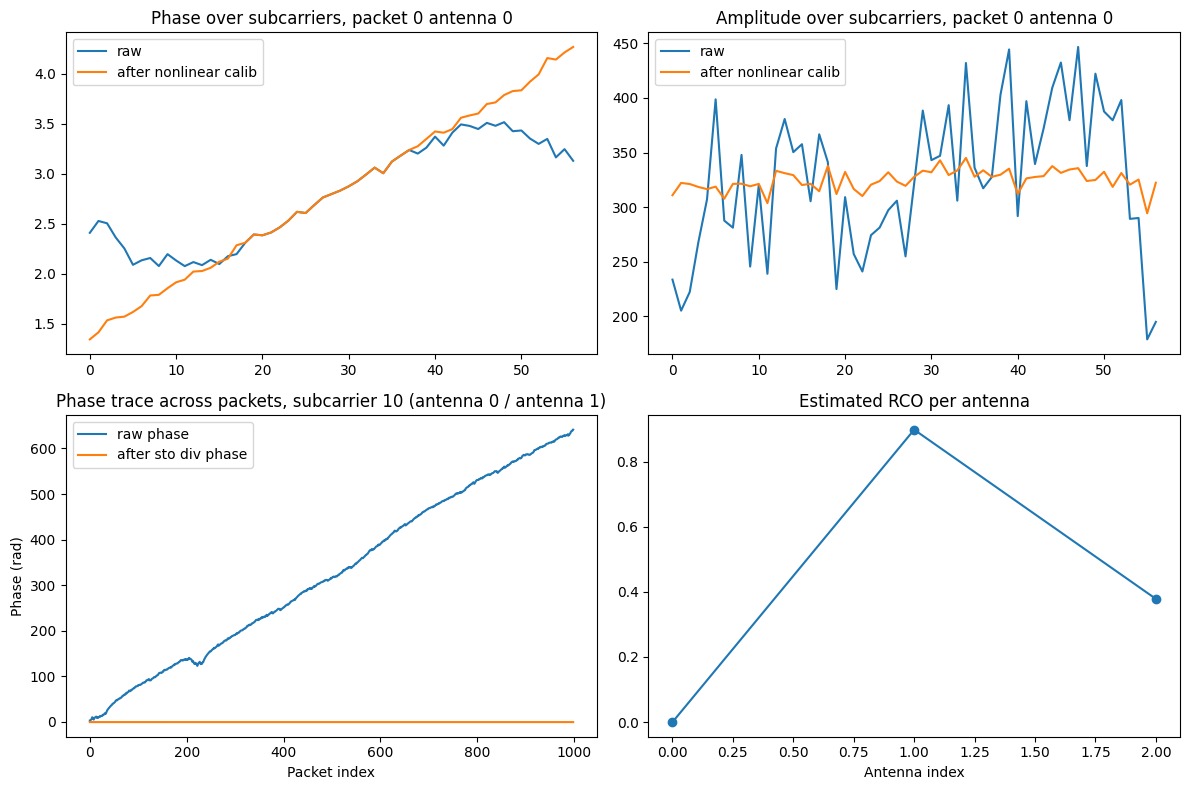

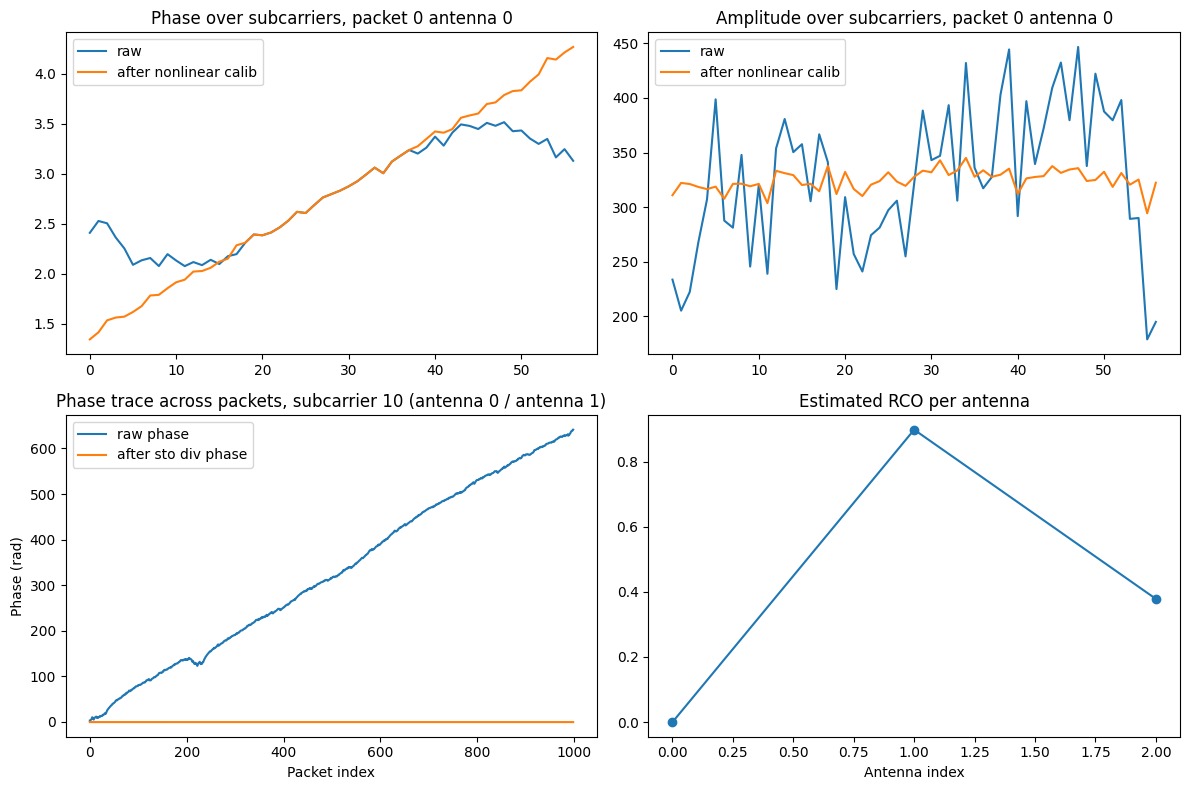

In [55]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    raw_phase = np.unwrap(np.angle(csi_src[0, :, 0, 0]))
    nl_phase = np.unwrap(np.angle(csi_remove_nonlinear_py[0, :, 0, 0]))
    axes[0, 0].plot(raw_phase, label='raw')
    axes[0, 0].plot(nl_phase, label='after nonlinear calib')
    axes[0, 0].set_title('Phase over subcarriers, packet 0 antenna 0')
    axes[0, 0].legend()

    axes[0, 1].plot(np.abs(csi_src[0, :, 0, 0]), label='raw')
    axes[0, 1].plot(np.abs(csi_remove_nonlinear_py[0, :, 0, 0]), label='after nonlinear calib')
    axes[0, 1].set_title('Amplitude over subcarriers, packet 0 antenna 0')
    axes[0, 1].legend()

    # axes[1, 0].plot(np.real(csi_src[:, 10, 0, 0]), label='raw real')
    # axes[1, 0].plot(np.real(csi_remove_sto_div_py[:, 10, 0, 0]), label='sto div real')
    # axes[1, 0].set_title('One subcarrier trace across packets')
    subcarrier_idx = 10
    raw_phase_trace = np.unwrap(np.angle(csi_src[:, subcarrier_idx, 0, 0]))
    sto_div_phase_trace = np.unwrap(np.angle(csi_remove_sto_div_py[:, subcarrier_idx, 0, 0]))
    axes[1, 0].plot(raw_phase_trace, label='raw phase')
    axes[1, 0].plot(sto_div_phase_trace, label='after sto div phase')
    axes[1, 0].set_title('Phase trace across packets, subcarrier 10 (antenna 0 / antenna 1)')
    axes[1, 0].set_xlabel('Packet index')
    axes[1, 0].set_ylabel('Phase (rad)')
    axes[1, 0].legend()

    axes[1, 1].plot(est_rco_py.squeeze(), marker='o')
    axes[1, 1].set_title('Estimated RCO per antenna')
    axes[1, 1].set_xlabel('Antenna index')

    fig.tight_layout()
    display_figure(fig)
else:
    print('Matplotlib not available, skipping visualization')

- Ô trên trái Phase over subcarriers: đúng. Sau nonlinear_calib, đường pha theo subcarrier mượt hơn và gần tuyến tính hơn. Đây chính là dấu hiệu đã bỏ được phần méo phi tuyến cố định của phần cứng.

- Ô trên phải Amplitude over subcarriers: đúng. Đường cam bớt răng cưa hơn raw, cho thấy template calibration đang làm phẳng méo biên độ theo subcarrier.

- Ô dưới phải Estimated RCO per antenna: hợp lý. Antenna 0 bằng 0 là mốc tham chiếu; antenna 1 và 2 có offset khác 0 là bình thường. Ở đây điều quan trọng là độ lệch tương đối giữa các antenna, không phải giá trị tuyệt đối.

- Ô dưới trái bây giờ là phần đẹp nhất để đọc: raw phase tăng gần tuyến tính rất mạnh theo packet, còn after sto div phase gần như phẳng. Điều này là đúng kỳ vọng, vì sto_calib_div đang triệt bớt thành phần pha chung theo packet. Nói ngắn gọn: trước sanitize thì phase bị drift mạnh, sau sanitize thì ổn định hơn nhiều.

## Interpret the outputs

- `set_template` learns a reference nonlinear distortion template from calibration CSI.
- `nonlinear_calib` divides by that template after phase unwrapping.
- `sto_calib_mul` and `sto_calib_div` remove common impairments by relating adjacent antennas.
- `rco_calib` estimates persistent radio-chain phase offsets.
- `cfo_calib` uses the phase gap between LTF slices to estimate offset.
- `naive_intrusion` is a lightweight FFT-energy heuristic, not a learned model.

This chapter is the bridge between raw CSI and more trustworthy features.